In [1]:
!pip install -q qdrant-client sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.9/389.9 kB 11.5 MB/s eta 0:00:00


## **Download & Load the Embedding Model**

### **What is an Embedding Model?**

It is a model that converts text (or any other data) to fixed length numerical vectors (1D Arrays) that capture the semantic meaning of the input text (or data).

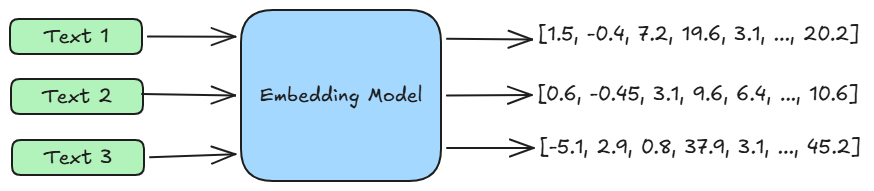

We are going to use the Sentence Transformer library by HuggingFace which allows us to download and use opensource embedding models from HuggingFace.

> HuggingFace is like the GitHub of AI, where the AI community collaborates on models, datasets, and applications.

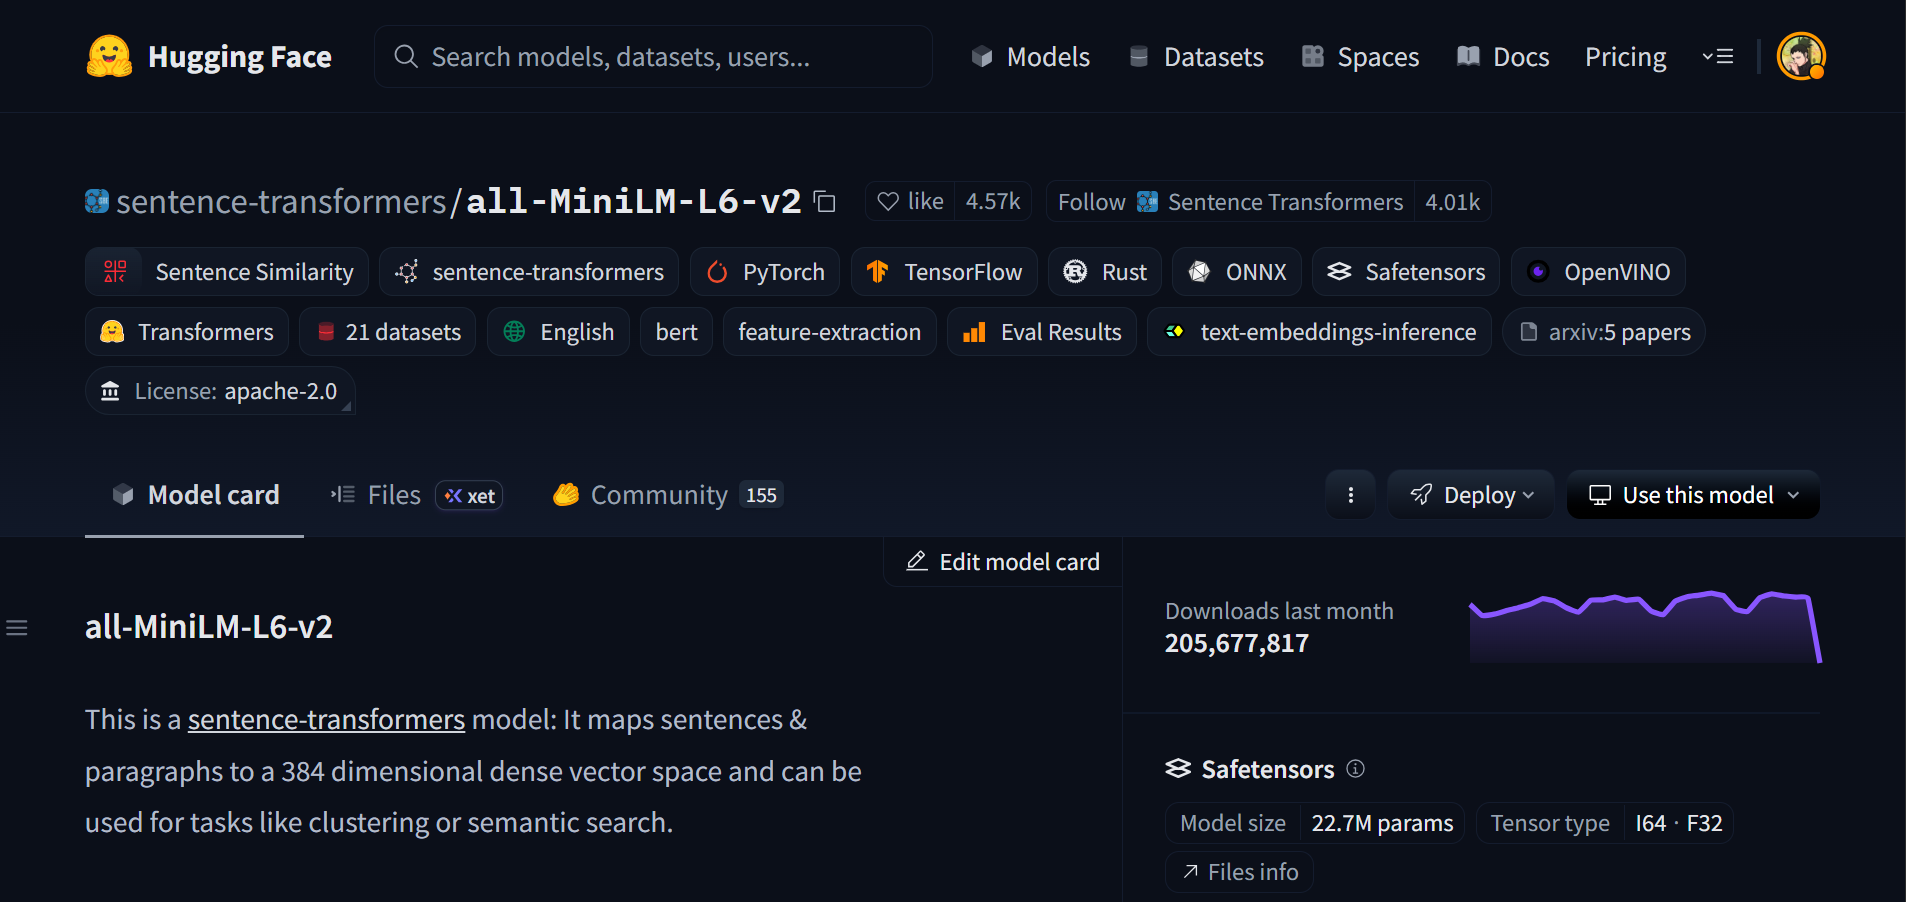

In [2]:
from sentence_transformers import SentenceTransformer

EMBEDDING_MODEL = "all-MiniLM-L6-v2"
embedder = SentenceTransformer(EMBEDDING_MODEL)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

### **In this Example:**
Here we have some texts in `docs` array (think of it like some docuemnts) and a `query` text.

We're going to encode them into embeddings & find out which documents are closely related to our query text.

In [3]:
# Example Documents
docs = [
    "Dogs are loyal and friendly domestic animals.",                  # text_1
    "Cats are independent and curious creatures.",                    # text_2
    "The Milky Way galaxy contains over 200 billion stars."           # text_3
    ]

In [4]:
# Creating Embedding
embedding = embedder.encode(docs)
embedding.shape

(3, 384)

In [5]:
# Creating Embedding of the "Query" text.
query = "What animals make good pets?"
query_embedding = embedder.encode(query)

In [6]:
# Calculate "Similarity" between text_1 & query
score_1 = embedder.similarity(query_embedding, embedding[0])
score_1

tensor([[0.5665]])

In [7]:
# Calculate "Similarity" between text_2 & query
score_2 = embedder.similarity(query_embedding, embedding[1])
score_2

tensor([[0.3954]])

In [8]:
# Calculate "Similarity" between text_3 & query
score_3 = embedder.similarity(query_embedding, embedding[2])
score_3

tensor([[0.0029]])

<br>

</br>

</br>

</br>

</br>

# **Vector Database**

### **What is a Vector Database?**
A vector database is a specialized storage system designed to manage, index, and query high-dimensional vector embeddings

### **What is a Qdrant?**

Qdrant is an OpenSource, high performance vector database. It specializes in storing, managing, and searching high-dimensional vectors, like those generated by AI models, along with associated metadata (payloads).

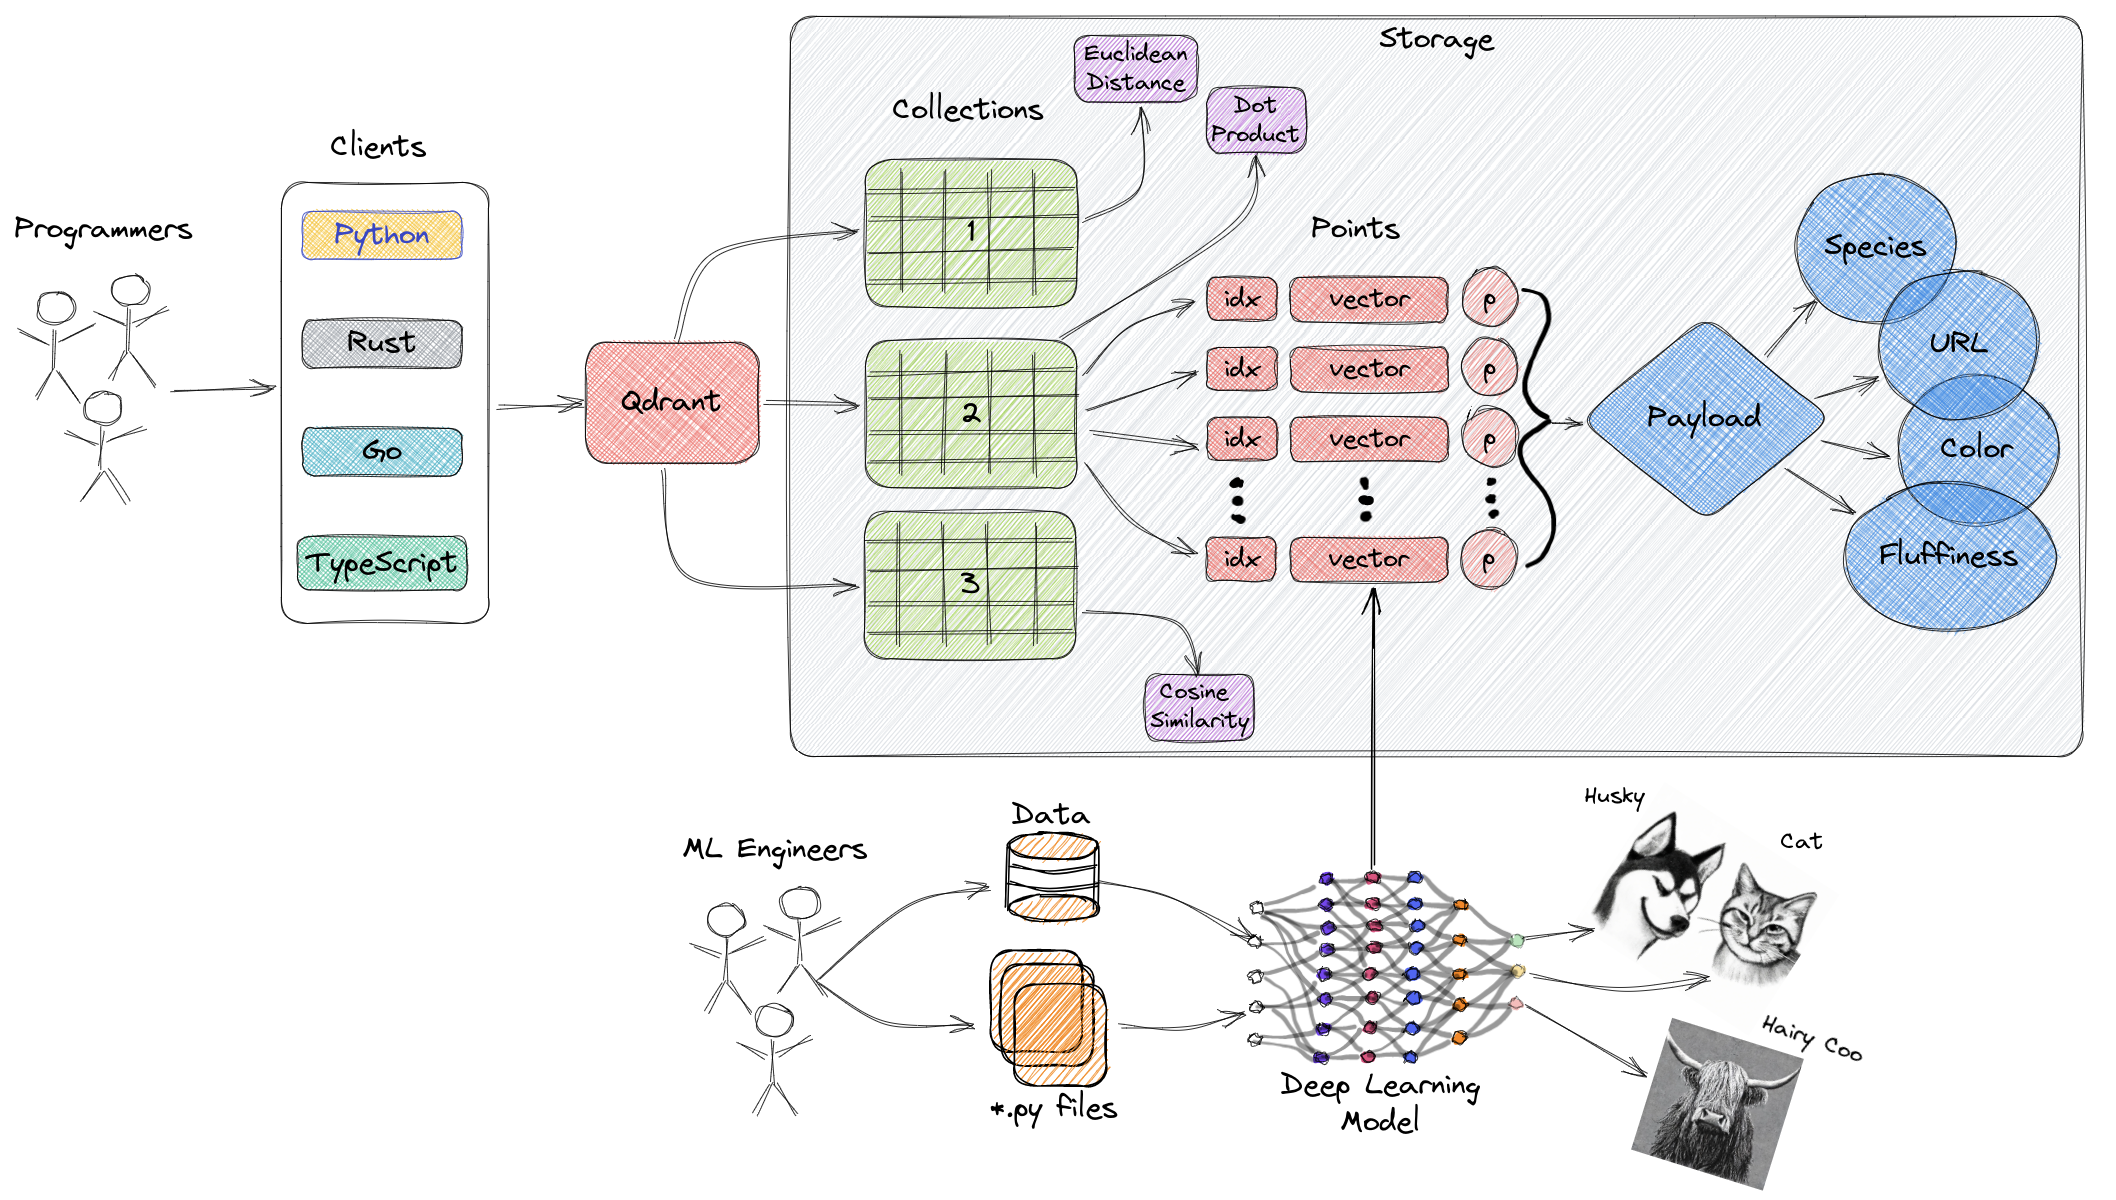

In [9]:
from qdrant_client import QdrantClient
from qdrant_client.models import (
    Distance, VectorParams, PointStruct,
    Filter, FieldCondition, MatchValue,
)

# "path" = no server needed for demos
# Production use: QdrantClient(url="http://localhost:6333")

# Connecting to a local instance
client = QdrantClient(path="/tmp/my_qdrant")

### **What is a collection?**

In Qdrant, a collection is a named, logical container that stores a set of related data points, which consist of vectors and optional metadata (payloads).

It serves a similar purpose to a table in a traditional mysql database.

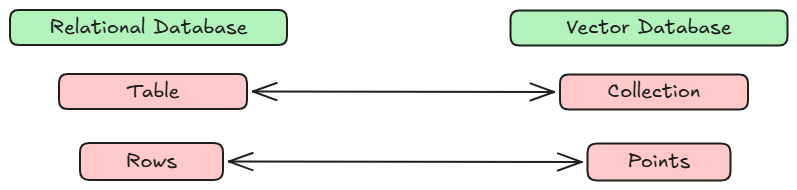

In [10]:
# Creating a Collection

COLLECTION_NAME = "docs"
DIM = embedder.get_sentence_embedding_dimension()

client.create_collection(
    collection_name=COLLECTION_NAME,
    vectors_config=VectorParams(
        size=DIM,
        distance=Distance.COSINE,
    ),
)
print("Collection created.")

Collection created.


Qdrant stores data in an entity called `point`. A point is a record consisting of a vector and an optional payload (similar to a row in MySql).

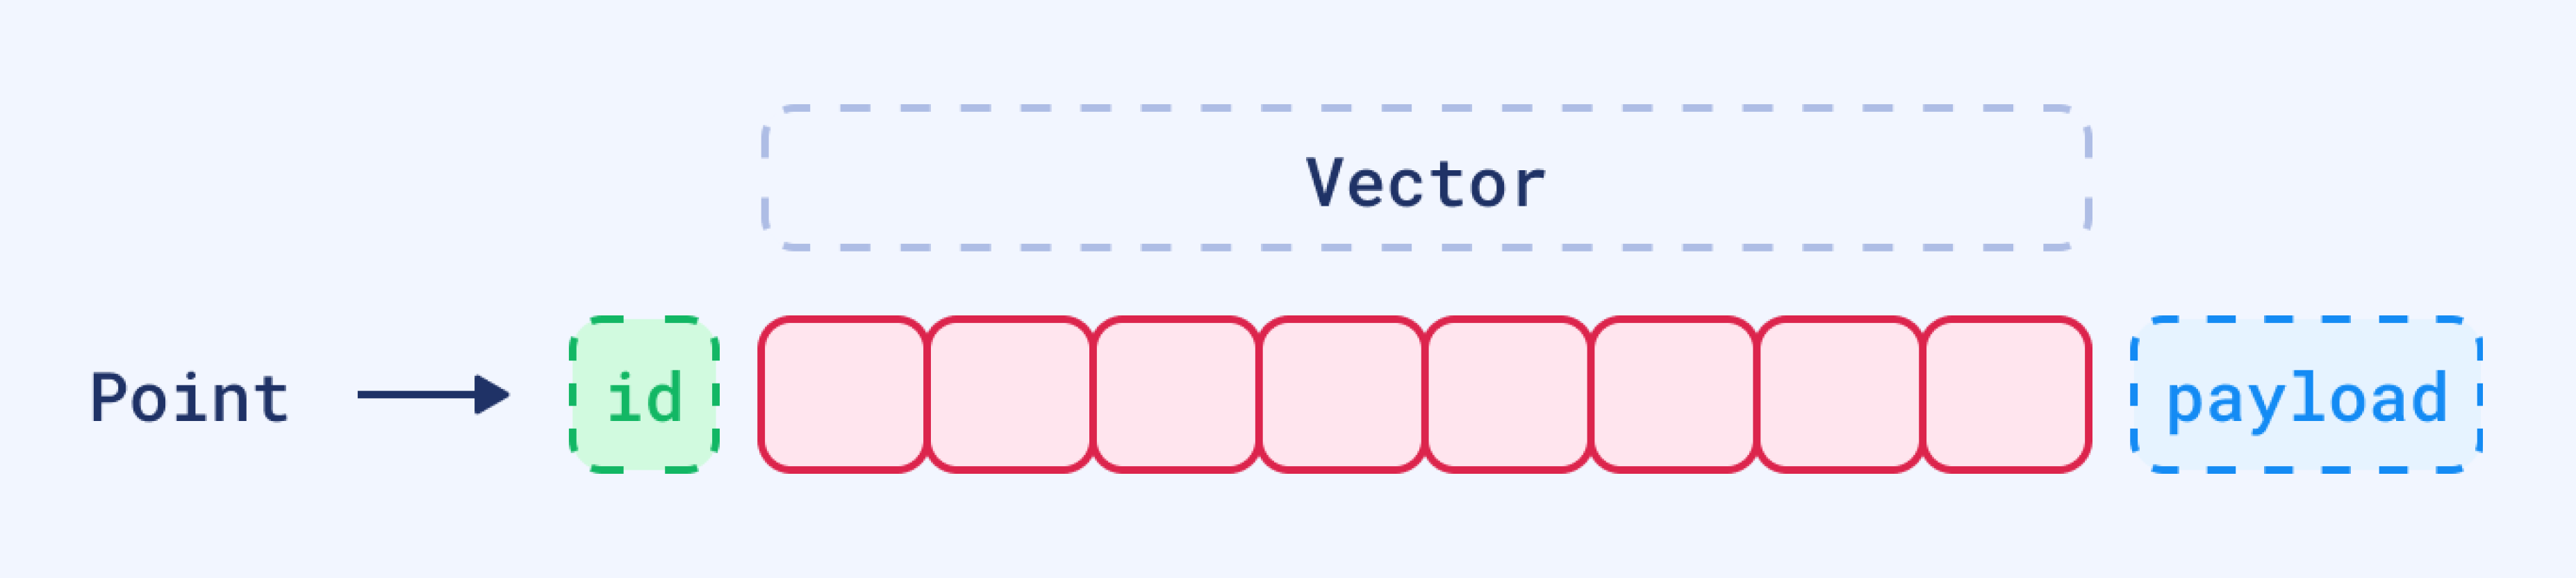

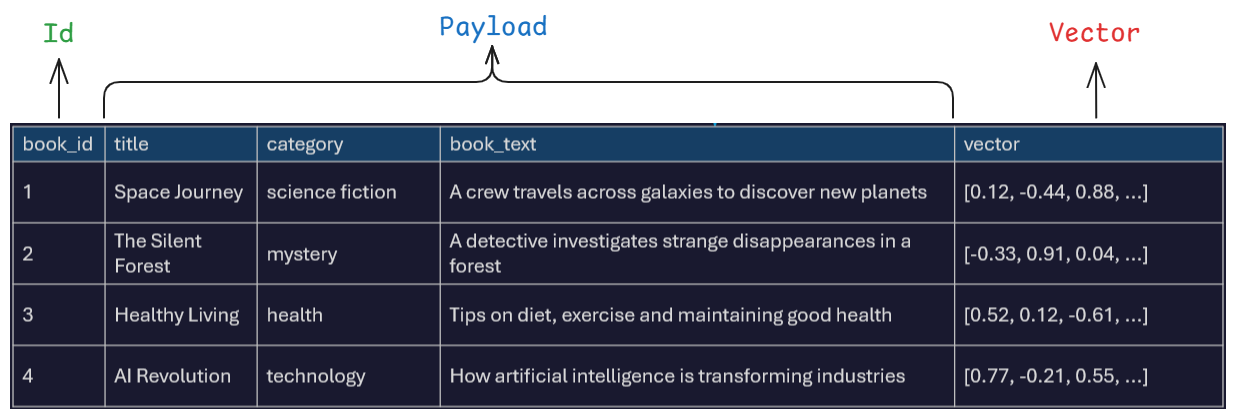

In [11]:
# Creating points to store in the vector db

points = [
    PointStruct(
        id=idx,
        vector=embedding[idx].tolist(),
        payload={
            "text":docs[idx]
        },
    ) for idx, doc in enumerate(docs)
]

In [12]:
# bulk inserting the points

response = client.upsert(
    collection_name=COLLECTION_NAME,
    points=points,
    wait=True,
)

response.status

<UpdateStatus.COMPLETED: 'completed'>

In [13]:
# Querying Demo

query     = "What animals make good pets?"
query_vec = embedder.encode(query).tolist()

In [14]:
results = client.query_points(
    collection_name=COLLECTION_NAME,
    query=query_vec,
    limit=3,
    #score_threshold=0.30
)

for r in results.points:
    print(f"Score: {r.score:.4f} | {r.payload['text']}")

Score: 0.5665 | Dogs are loyal and friendly domestic animals.
Score: 0.3954 | Cats are independent and curious creatures.
Score: 0.0029 | The Milky Way galaxy contains over 200 billion stars.


In [ ]:
# 💡Fun Fact: You can also limit the relevant docs by score
results = client.query_points(
    collection_name=COLLECTION_NAME,
    query=query_vec,
    limit=3,
    score_threshold=0.30
)

for r in results.points:
    print(f"Score: {r.score:.4f} | {r.payload['text']}")